**Задание на лабораторную работу №5**  
Выделить на изображении маслины  

In [78]:
from google.colab import files
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.colors import hsv_to_rgb
from matplotlib import colors

In [79]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
image = cv2.imread('/content/drive/MyDrive/Image_processing/salad.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

Просмотр исходного изображения


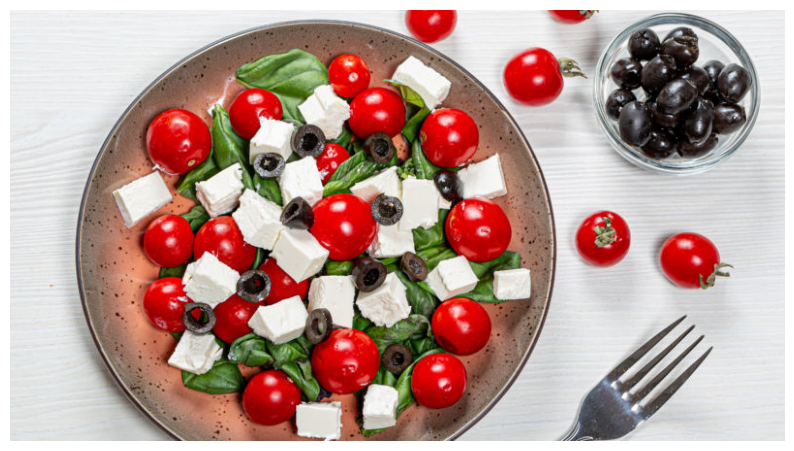

In [81]:
plt.figure(figsize=(10, 8))
plt.gca().set_axis_off()
plt.imshow(image_rgb)

Преобразование изображения в цветовую модель HSV

In [82]:
image_hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

Маски для разных оттенков цвета маслин

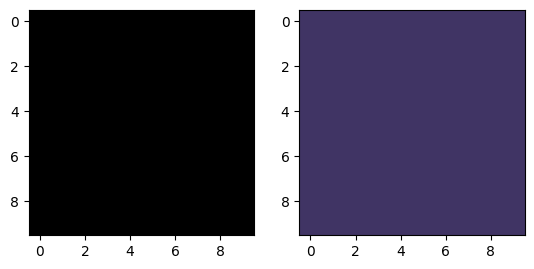

In [83]:
lower_gray = np.array([0, 0, 0])
upper_gray = np.array([180, 120, 100])
lo_square = np.full((10, 10, 3), lower_gray, dtype=np.uint8) / 255.0
up_square = np.full((10, 10, 3), upper_gray, dtype=np.uint8) / 255.0

plt.subplot(1, 2, 1)
plt.imshow(hsv_to_rgb(lo_square))
plt.subplot(1, 2, 2)
plt.imshow(hsv_to_rgb(up_square))
plt.show()

Найдем на изображении цвета, подходящие под маску, добавим маску на изображение.

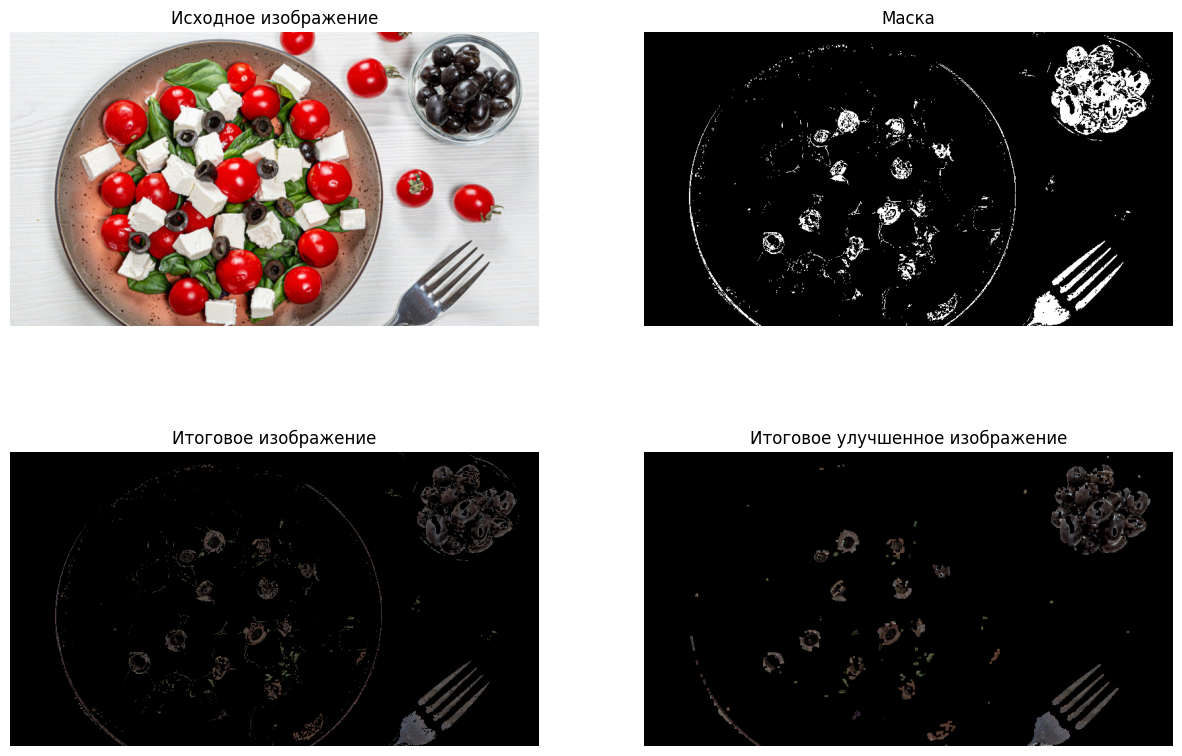

In [84]:
mask = cv2.inRange(image_hsv, lower_gray, upper_gray)

kernel = np.ones((3, 3), np.uint8)
# Закрытие (заполнение маленьких дырок)
mask_cleaned = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
# Открытие (удаление маленьких шумов)
mask_cleaned = cv2.morphologyEx(mask_cleaned, cv2.MORPH_OPEN, kernel)

result = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
result_clean = cv2.bitwise_and(image_rgb, image_rgb, mask=mask_cleaned)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Исходное изображение")

plt.subplot(2, 2, 2)
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.title("Маска")

plt.subplot(2, 2, 3)
plt.imshow(result)
plt.axis("off")
plt.title("Итоговое изображение")

plt.subplot(2, 2, 4)
plt.imshow(result_clean)
plt.axis("off")
plt.title("Итоговое улучшенное изображение")

plt.show()